In [38]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
data = {
    'outlook': [
        'sunny', 'sunny', 'overcast', 'rainy',
        'rainy', 'rainy', 'overcast', 'sunny',
        'sunny', 'rainy', 'sunny', 'overcast',
        'overcast', 'rainy'
    ],
    
    'temp': [
        'hot', 'hot', 'hot', 'mild',
        'cool', 'cool', 'cool', 'mild',
        'cool', 'mild', 'mild', 'mild',
        'hot', 'mild'
    ],
    
    'humidity': [
        'high', 'high', 'high', 'high',
        'normal', 'normal', 'normal', 'high',
        'normal', 'normal', 'normal', 'high',
        'normal', 'high'
    ],
    
    'windy': [
        False, True, False, False,
        False, True, True, False,
        False, False, True, True,
        False, True
    ],
    
    'play': [
        'no', 'no', 'yes', 'yes',
        'yes', 'no', 'yes', 'no',
        'yes', 'yes', 'yes', 'yes',
        'yes', 'no'
    ]
}

df = pd.DataFrame(data)

In [40]:
print(df.columns)
print(df.info())

Index(['outlook', 'temp', 'humidity', 'windy', 'play'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   outlook   14 non-null     str  
 1   temp      14 non-null     str  
 2   humidity  14 non-null     str  
 3   windy     14 non-null     bool 
 4   play      14 non-null     str  
dtypes: bool(1), str(4)
memory usage: 594.0 bytes
None


In [41]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [42]:
print(df['play'].value_counts())

play
yes    9
no     5
Name: count, dtype: int64


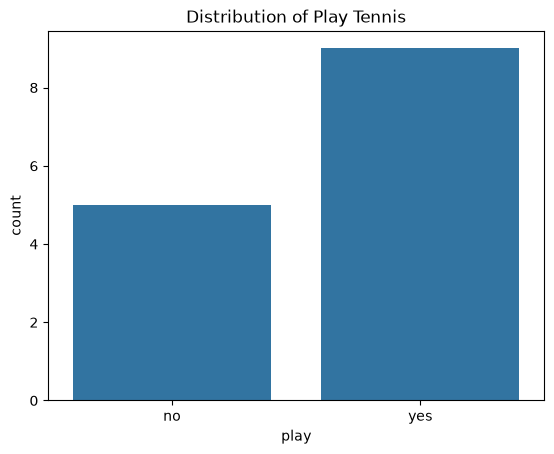

In [43]:
sns.countplot(data=df, x='play')
plt.title('Distribution of Play Tennis')
plt.show()

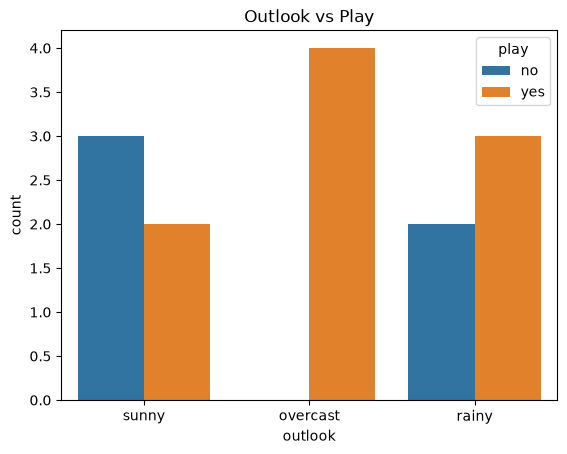

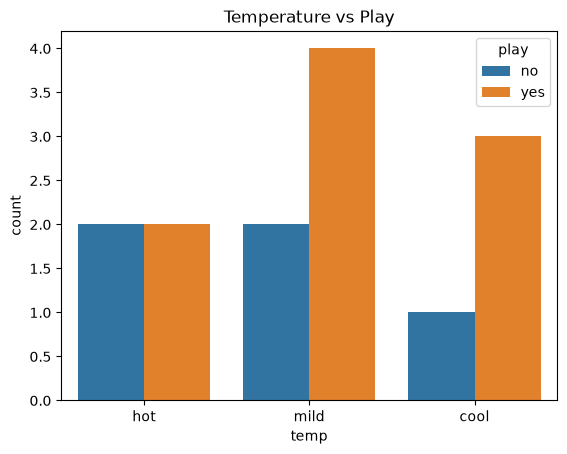

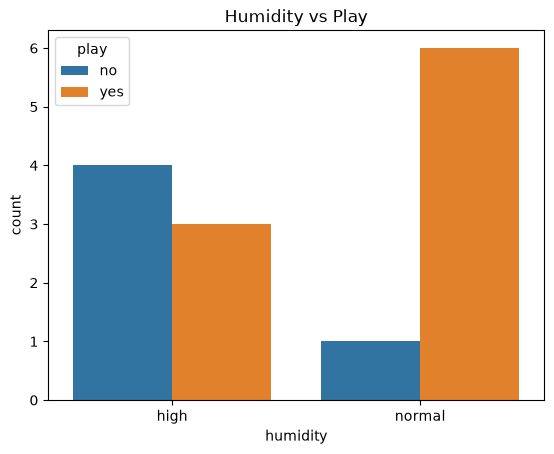

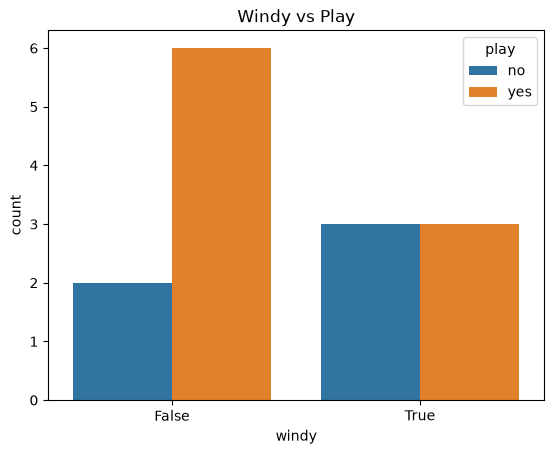

In [44]:
# Outlook vs Play
sns.countplot(data=df, x='outlook', hue='play')
plt.title('Outlook vs Play')
plt.show()

# Temperature vs Play
sns.countplot(data=df, x='temp', hue='play')
plt.title('Temperature vs Play')
plt.show()

# Humidity vs Play
sns.countplot(data=df, x='humidity', hue='play')
plt.title('Humidity vs Play')
plt.show()

# Windy vs Play
sns.countplot(data=df, x='windy', hue='play')
plt.title('Windy vs Play')
plt.show()

## Encoding the categorical data

In [45]:
# Create encoders
encoders = {}

for column in df.columns:
    encoders[column] = LabelEncoder()
    df[column] = encoders[column].fit_transform(df[column])

print(df)

    outlook  temp  humidity  windy  play
0         2     1         0      0     0
1         2     1         0      1     0
2         0     1         0      0     1
3         1     2         0      0     1
4         1     0         1      0     1
5         1     0         1      1     0
6         0     0         1      1     1
7         2     2         0      0     0
8         2     0         1      0     1
9         1     2         1      0     1
10        2     2         1      1     1
11        0     2         0      1     1
12        0     1         1      0     1
13        1     2         0      1     0


## Separate the features and target

In [46]:
x = df.drop('play', axis=1)
y = df['play']

print("Features:")
print(x)

print("\nTarget:")
print(y)

Features:
    outlook  temp  humidity  windy
0         2     1         0      0
1         2     1         0      1
2         0     1         0      0
3         1     2         0      0
4         1     0         1      0
5         1     0         1      1
6         0     0         1      1
7         2     2         0      0
8         2     0         1      0
9         1     2         1      0
10        2     2         1      1
11        0     2         0      1
12        0     1         1      0
13        1     2         0      1

Target:
0     0
1     0
2     1
3     1
4     1
5     0
6     1
7     0
8     1
9     1
10    1
11    1
12    1
13    0
Name: play, dtype: int64


In [47]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.3
)

In [48]:
x_train

,outlook,temp,humidity,windy
4,1,0,1,0
2,0,1,0,0
13,1,2,0,1
8,2,0,1,0
11,0,2,0,1
12,0,1,1,0
10,2,2,1,1
5,1,0,1,1
0,2,1,0,0


In [49]:
x_test

,outlook,temp,humidity,windy
1,2,1,0,1
3,1,2,0,0
6,0,0,1,1
9,1,2,1,0
7,2,2,0,0


In [50]:
model = CategoricalNB()

model.fit(x_train, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[0., 2...[3., 1., 2.]]), array([[1., 1...[2., 2., 2.]]), array([[2., 1... [2., 4.]]), array([[1., 2... [4., 2.]])]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3.,6.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-1.1 ,-0.41]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-1.79...-1.09861229]]), array([[-1.09...-1.09861229]]), array([[-0.51...-0.47000363]]), array([[-0.91...-0.98082925]])]"


In [51]:
y_pred = model.predict(x_test)

print("Actual values:")
print(y_test.values)

print("Predicted values:")
print(y_pred)

Actual values:
[0 1 1 1 0]
Predicted values:
[0 0 1 1 1]


In [52]:
accuracy_score(y_test, y_pred)

0.6

In [53]:
print(classification_report(y_test, y_pred, zero_division = 0))

              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5



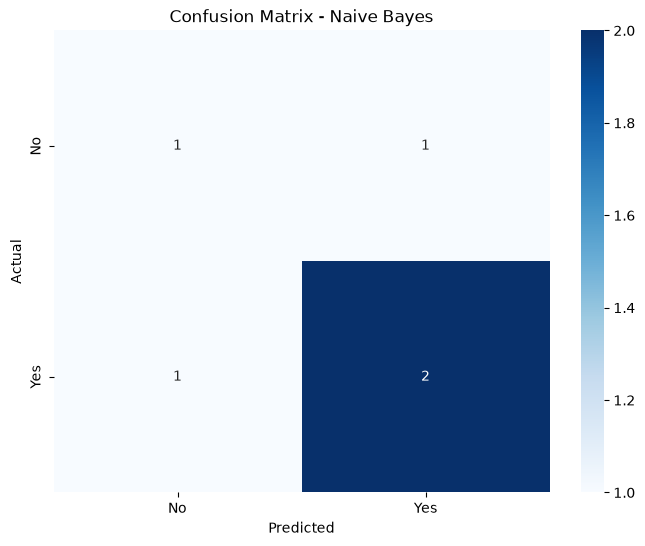

In [54]:
cm= confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

### Test data

In [55]:
sample_data = pd.DataFrame({
    'outlook': ['sunny', 'overcast', 'rainy', 'sunny', 'rainy'],
    'temp': ['cool', 'hot', 'mild', 'hot', 'cool'],
    'humidity': ['normal', 'high', 'normal', 'high', 'normal'],
    'windy': ['false', 'false', 'false', 'true', 'true']
})

# Encode using the existing encoders
for column in sample_data.columns:
    sample_data[column] = encoders[column].transform(sample_data[column])

# Predict
predictions = model.predict(sample_data)

# Convert predictions back to yes/no
predicted_play = encoders['play'].inverse_transform(predictions)

print(predicted_play)

['yes' 'yes' 'no' 'no' 'no']
